Seuil minimal: 5, échantillons après filtrage: 0
Seuil minimal: 4, échantillons après filtrage: 4


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



Model Evaluation:
Accuracy: 1.0000
F1 Score (macro): 1.0000
F1 Score (weighted): 1.0000
Precision: 1.0000
Recall: 1.0000

Classification Report:
              precision    recall  f1-score   support

         363       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1


Confusion Matrix:
[[1]]


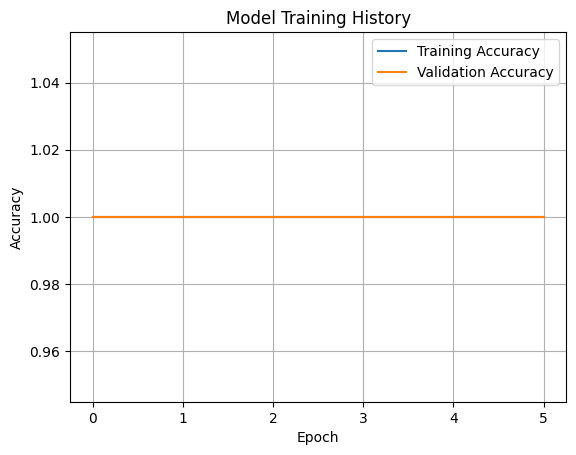

In [13]:
####LSTM####
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, f1_score,
                             accuracy_score, confusion_matrix,
                             precision_score, recall_score)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 1. Charger les données
df = pd.read_csv('cleaned_medical_symptoms.csv')

# 2. Identifier les colonnes catégorielles (hors target)
target_col = df.columns[-1]
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != target_col]

# 3. Encoder les colonnes catégorielles
le_dict = {}
df_encoded = df.copy()
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    le_dict[col] = le

# 4. Encoder provisoirement la cible pour filtrage
le_temp = LabelEncoder()
df_encoded[target_col] = le_temp.fit_transform(df_encoded[target_col])
y_temp = df_encoded[target_col].values

# 5. Filtrer les classes trop rares avec ajustement dynamique du seuil
min_samples_per_class = 5
value_counts = pd.Series(y_temp).value_counts()

while min_samples_per_class > 0:
    valid_classes = value_counts[value_counts >= min_samples_per_class].index
    df_filtered = df_encoded[df_encoded[target_col].isin(valid_classes)]
    print(f"Seuil minimal: {min_samples_per_class}, échantillons après filtrage: {df_filtered.shape[0]}")
    if df_filtered.shape[0] > 0:
        break
    min_samples_per_class -= 1

if df_filtered.shape[0] == 0:
    raise ValueError("Aucun échantillon disponible après filtrage, même avec seuil minimal = 1.")

# 6. Mettre à jour X et y
X = df_filtered.drop(columns=[target_col]).values

# Re-encoder la cible correctement après filtrage
le_target = LabelEncoder()
y = le_target.fit_transform(df_filtered[target_col].values)
num_classes = len(le_target.classes_)

# 7. Standardisation des features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 8. Reshape pour LSTM : [samples, timesteps=1, features]
X = X.reshape(X.shape[0], 1, X.shape[1])

# 9. Découpage train/test stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y)

# 10. One-hot encode des cibles
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# 11. Création du modèle LSTM
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 12. Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 13. Entraînement
history = model.fit(X_train, y_train_cat,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_test, y_test_cat),
                    callbacks=[early_stop],
                    verbose=1)

# 14. Prédictions
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# 15. Évaluation
print("\nModel Evaluation:")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1 Score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.4f}")

# Correction ici pour le classification_report
target_names = le_target.inverse_transform(np.unique(y_test)).astype(str)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 16. Affichage des courbes d'entraînement
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Training History')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()


Min_samples utilisé pour filtrage: 4
Utilisation de n_splits=4 pour la cross-validation
Cross-validation Accuracy: 1.0000 ± 0.0000


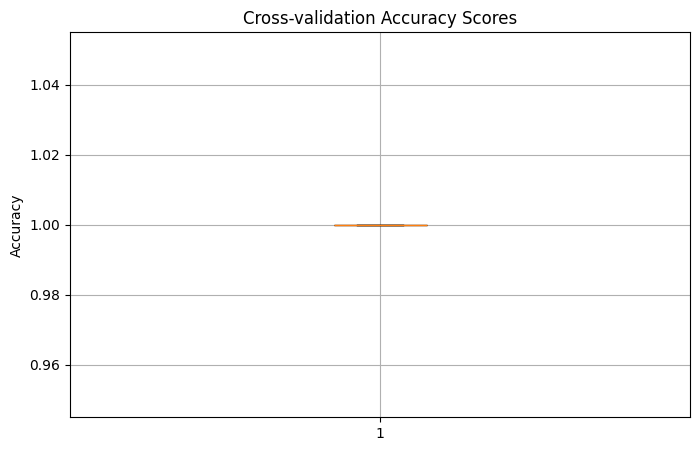


Evaluation sur test set:
Accuracy: 1.0000
F1 macro: 1.0000
Classification Report:
                                                                                                                                     precision    recall  f1-score   support

feel extremely scratchy sick wear addition lose weight temperature urine dark skin turn yellow additionally experience stomach pain       1.00      1.00      1.00         1

                                                                                                                           accuracy                           1.00         1
                                                                                                                          macro avg       1.00      1.00      1.00         1
                                                                                                                       weighted avg       1.00      1.00      1.00         1



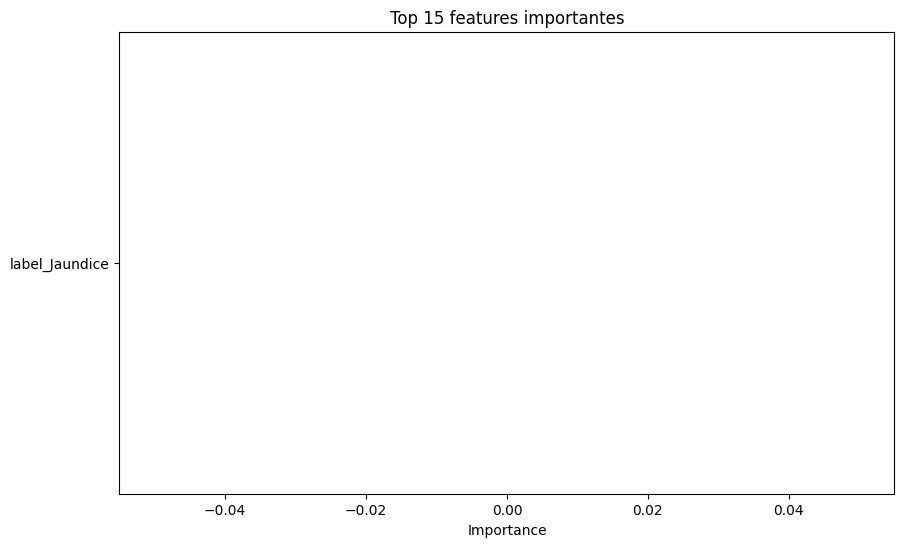

In [29]:
## AdaBoost####
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

# Charger données
df = pd.read_csv('cleaned_medical_symptoms.csv')

X = df.iloc[:, :-1]
y_raw = df.iloc[:, -1]

le = LabelEncoder()
y = le.fit_transform(y_raw)

# Filtrer classes pour stratification possible
def filter_classes_dynamic(X, y, test_size=0.2, min_samples_start=1, max_samples=20):
    for min_samples in range(min_samples_start, max_samples+1):
        value_counts = pd.Series(y).value_counts()
        valid_classes = value_counts[value_counts >= min_samples].index
        mask = np.isin(y, valid_classes)

        X_filtered = X.loc[mask]
        y_filtered = y[mask]

        class_sizes = pd.Series(y_filtered).value_counts()
        if len(class_sizes) == 0 or class_sizes.min() < 2:
            continue

        try:
            X_train, X_test, y_train, y_test = train_test_split(
                X_filtered, y_filtered, test_size=test_size, random_state=42, stratify=y_filtered)
            return X_train, X_test, y_train, y_test, min_samples, X_filtered, y_filtered
        except ValueError:
            continue
    raise ValueError("Impossible de trouver un seuil min_samples adapté pour un split stratifié.")

X_train, X_test, y_train, y_test, min_samples_used, X_filtered, y_filtered = filter_classes_dynamic(X, y, test_size=0.2)
print(f"Min_samples utilisé pour filtrage: {min_samples_used}")

# Colonnes catégorielles et numériques
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

base_estimator = DecisionTreeClassifier(max_depth=2)
ada_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

model_pipeline = make_pipeline(preprocessor, ada_model)

# Calcul n_splits possible
min_class_samples = pd.Series(y_filtered).value_counts().min()
n_splits = min(5, min_class_samples)
print(f"Utilisation de n_splits={n_splits} pour la cross-validation")

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

cv_scores = cross_val_score(model_pipeline, X_filtered, y_filtered, cv=cv)
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Plot cross-validation scores
plt.figure(figsize=(8, 5))
plt.boxplot(cv_scores, patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.title("Cross-validation Accuracy Scores")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Entraînement final
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

print("\nEvaluation sur test set:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Classification Report:\n{classification_report(y_test, y_pred, target_names=le.inverse_transform(np.unique(y_train)))}")

# Importance des features (seulement si AdaBoost expose feature_importances_)
# Récupérer noms features après OneHotEncoding (col transformer + pipeline)
feature_names_num = num_cols
feature_names_cat = model_pipeline.named_steps['columntransformer'].named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([feature_names_num, feature_names_cat])

importances = model_pipeline.named_steps['adaboostclassifier'].feature_importances_

# Plot feature importances top 15
indices = np.argsort(importances)[-15:][::-1]
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), all_feature_names[indices])
plt.xlabel("Importance")
plt.title("Top 15 features importantes")
plt.gca().invert_yaxis()
plt.show()


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.0985 - loss: 3.1690 - val_accuracy: 0.1250 - val_loss: 3.0435
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.2483 - loss: 2.7829 - val_accuracy: 0.3958 - val_loss: 1.9494
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6014 - loss: 1.6179 - val_accuracy: 0.7083 - val_loss: 1.1889
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8462 - loss: 0.7797 - val_accuracy: 0.7708 - val_loss: 0.8048
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9398 - loss: 0.3421 - val_accuracy: 0.8333 - val_loss: 0.5969
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9782 - loss: 0.2006 - val_accuracy: 0.8542 - val_loss: 0.5681
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9887 - loss: 0.1306 - val_accuracy: 0.8542 - val_loss: 0.5258
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9963 - loss: 0.0683 - val_accuracy: 0.8646 - val_loss: 0.

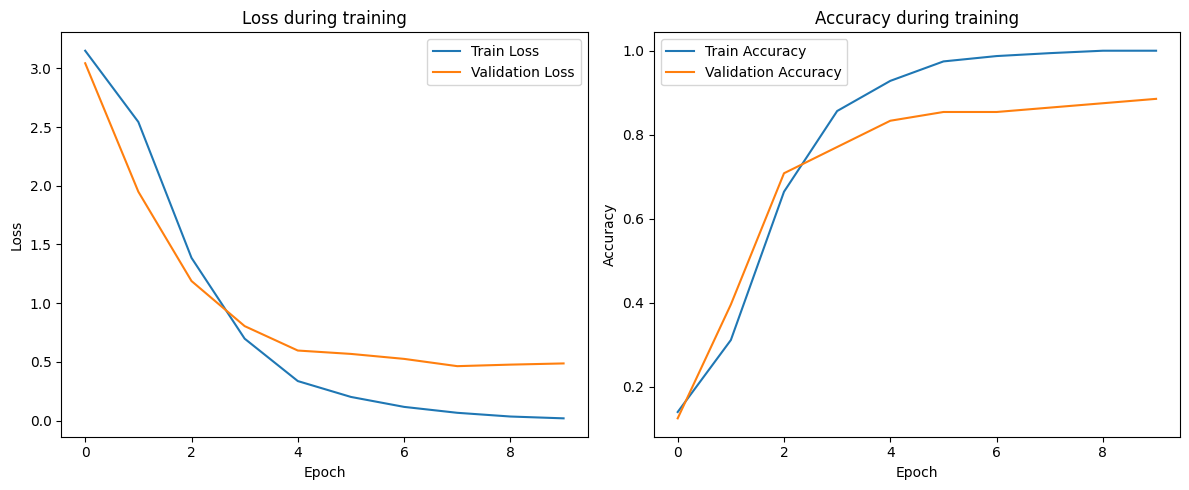

In [30]:
##RNN####
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Load cleaned data
df = pd.read_csv('cleaned_medical_symptoms.csv')

texts = df['cleaned_text'].astype(str).tolist()
labels = df['label'].astype(str).tolist()

# Tokenize texts
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=100)

# Save tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

pd.Series(le.classes_).to_csv('disease_labels.csv', index=False, header=False)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build model
model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    LSTM(64, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train model and save history
history = model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.1)



# Plot training & validation loss and accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss during training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy during training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Generating embeddings...
Embeddings done!
Epoch 1/15
54/54 - 2s - 28ms/step - accuracy: 0.2535 - loss: 2.8041 - val_accuracy: 0.4375 - val_loss: 2.2311
Epoch 2/15
54/54 - 1s - 9ms/step - accuracy: 0.5891 - loss: 1.6559 - val_accuracy: 0.6354 - val_loss: 1.4332
Epoch 3/15
54/54 - 0s - 6ms/step - accuracy: 0.7454 - loss: 0.9848 - val_accuracy: 0.7708 - val_loss: 0.9778
Epoch 4/15
54/54 - 0s - 6ms/step - accuracy: 0.8495 - loss: 0.6473 - val_accuracy: 0.7292 - val_loss: 0.8311
Epoch 5/15
54/54 - 1s - 11ms/step - accuracy: 0.8831 - loss: 0.4873 - val_accuracy: 0.7917 - val_loss: 0.6972
Epoch 6/15
54/54 - 0s - 5ms/step - accuracy: 0.9144 - loss: 0.3802 - val_accuracy: 0.7604 - val_loss: 0.6551
Epoch 7/15
54/54 - 0s - 6ms/step - accuracy: 0.9398 - loss: 0.2847 - val_accuracy: 0.8229 - val_loss: 0.5646
Epoch 8/15
54/54 - 1s - 11ms/step - accuracy: 0.9560 - loss: 0.2283 - val_accuracy: 0.7812 - val_loss: 0.6447
Epoch 9/15
54/54 - 0s - 6ms/step - accuracy: 0.9699 - loss: 0.1565 - val_accuracy: 

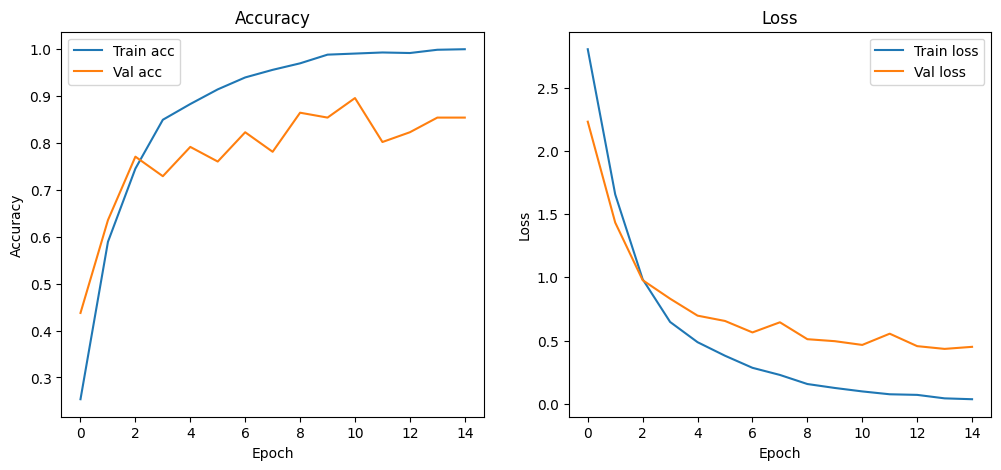

Test accuracy: 0.9000
Test loss: 0.3414


In [33]:

###BIOBERT##
import pandas as pd
import numpy as np
import os
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt
import random

# Disable oneDNN for compatibility (optional)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Load data
df = pd.read_csv('cleaned_medical_symptoms.csv')
texts = df['cleaned_text'].astype(str).tolist()
labels = df['label'].astype(str).tolist()

# Load BioBERT model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.1")
model_bert = AutoModel.from_pretrained("dmis-lab/biobert-base-cased-v1.1")

# Embedding function
def embed_text(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding='max_length', max_length=128)
    with torch.no_grad():
        outputs = model_bert(**inputs)
    # Mean pooling of last hidden states
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

# Compute embeddings (this might take a while)
print("Generating embeddings...")
X = np.vstack([embed_text(t) for t in texts])
print("Embeddings done!")

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)
pd.Series(le.classes_).to_csv('disease_labels.csv', index=False, header=False)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Build Keras model
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train model with history
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=16,
    validation_split=0.1,
    verbose=2
)

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")


Classification Report:
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00         7
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       0.92      1.00      0.96        11
           Cervical spondylosis       1.00      1.00      1.00         7
                    Chicken pox       0.67      0.50      0.57        12
                    Common Cold       1.00      0.75      0.86        12
                         Dengue       0.64      0.58      0.61        12
          Dimorphic Hemorrhoids       1.00      1.00      1.00         7
               Fungal infection       1.00      1.00      1.00        13
                   Hypertension       1.00      0.90      0.95        10
                       Impetigo       0.85      1.00      0.92        11
                       Jaundice       1.00      1.00      1.00        11
                        Mal

<Figure size 1200x1200 with 0 Axes>

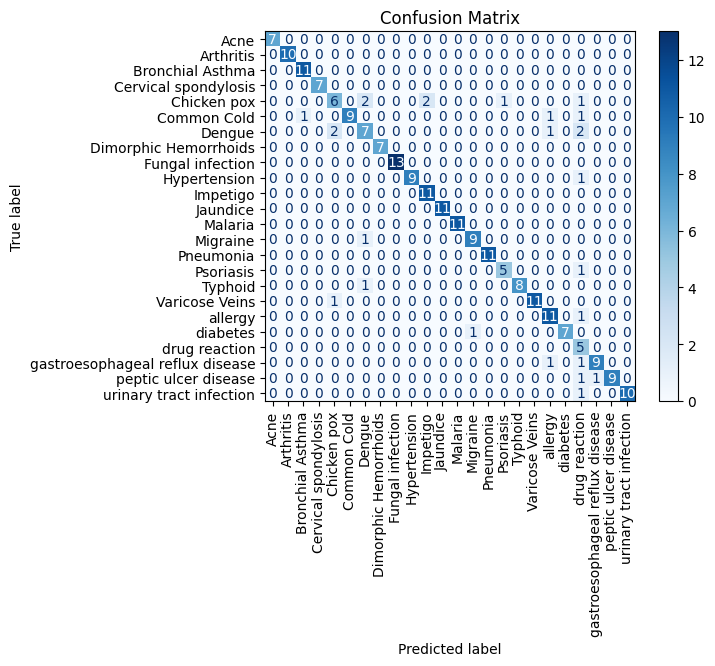

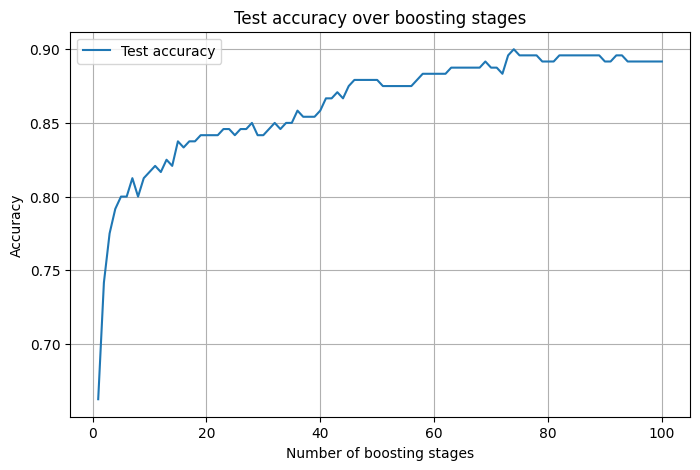

In [34]:
####gradient_boosing############


import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('cleaned_medical_symptoms.csv')

# Prepare features
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_text'].astype(str))

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['label'].astype(str))

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build model
model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    random_state=42,
    subsample=0.8
)

# Train model
model.fit(X_train, y_train)

# Predictions on test set
y_pred = model.predict(X_test)

# Evaluation report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
plt.figure(figsize=(12,12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)
plt.title("Confusion Matrix")
plt.show()

# --- Plot accuracy over boosting stages ---
test_accuracies = []
for y_pred_stage in model.staged_predict(X_test):
    test_accuracies.append(accuracy_score(y_test, y_pred_stage))

plt.figure(figsize=(8,5))
plt.plot(range(1, len(test_accuracies)+1), test_accuracies, label='Test accuracy')
plt.xlabel('Number of boosting stages')
plt.ylabel('Accuracy')
plt.title('Test accuracy over boosting stages')
plt.legend()
plt.grid(True)
plt.show()


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       0.83      1.00      0.91        10
           2       0.92      1.00      0.96        11
           3       0.88      1.00      0.93         7
           4       0.67      0.50      0.57        12
           5       1.00      0.83      0.91        12
           6       1.00      0.58      0.74        12
           7       1.00      1.00      1.00         7
           8       0.93      1.00      0.96        13
           9       1.00      1.00      1.00        10
          10       0.73      1.00      0.85        11
          11       1.00      1.00      1.00        11
          12       0.85      1.00      0.92        11
          13       1.00      0.90      0.95        10
          14       1.00      1.00      1.00        11
          15       0.80      0.67      0.73         6
          16       0.89      0.89      0.89         9
          17       0.79    

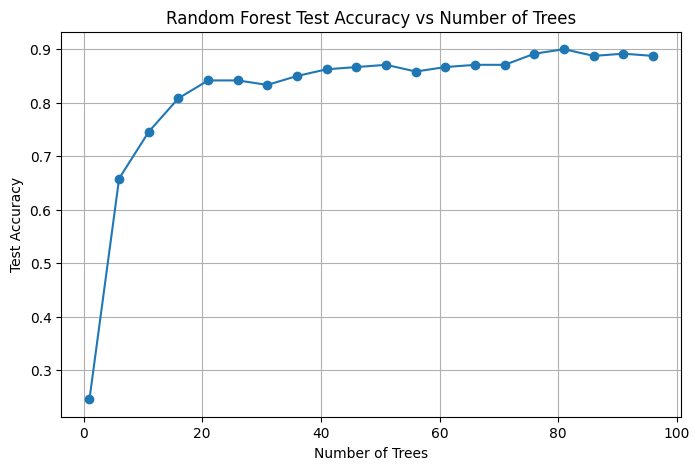

Random Forest model trained and saved successfully!


In [35]:
####random_forest###########

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import joblib
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('cleaned_medical_symptoms.csv')

# Vectorize text with TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(df['cleaned_text'].astype(str))

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['label'].astype(str))

# Save TF-IDF vectorizer and label encoder
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
joblib.dump(le, 'label_encoder.pkl')
pd.Series(le.classes_).to_csv('disease_classes.csv', index=False, header=False)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Train and evaluate Random Forest incrementally by number of trees
n_estimators_list = list(range(1, 101, 5))  # from 1 to 100 trees, step 5
accuracies = []

for n_trees in n_estimators_list:
    model = RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=10,
        min_samples_split=2,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Train final model with full number of trees
final_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
final_model.fit(X_train, y_train)

# Save final model
joblib.dump(final_model, 'random_forest_model.pkl')

# Final evaluation report
y_pred_final = final_model.predict(X_test)
print(classification_report(y_test, y_pred_final))

# Plot accuracy over number of trees
plt.figure(figsize=(8,5))
plt.plot(n_estimators_list, accuracies, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Test Accuracy")
plt.title("Random Forest Test Accuracy vs Number of Trees")
plt.grid(True)
plt.show()

print("Random Forest model trained and saved successfully!")


Classification Report:
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00         7
                      Arthritis       0.83      1.00      0.91        10
               Bronchial Asthma       0.92      1.00      0.96        11
           Cervical spondylosis       0.88      1.00      0.93         7
                    Chicken pox       0.67      0.50      0.57        12
                    Common Cold       1.00      0.83      0.91        12
                         Dengue       1.00      0.58      0.74        12
          Dimorphic Hemorrhoids       1.00      1.00      1.00         7
               Fungal infection       0.93      1.00      0.96        13
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       0.73      1.00      0.85        11
                       Jaundice       1.00      1.00      1.00        11
                        Mal

<Figure size 1200x1000 with 0 Axes>

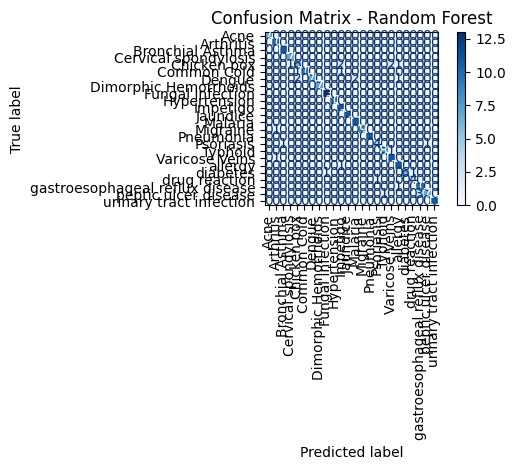

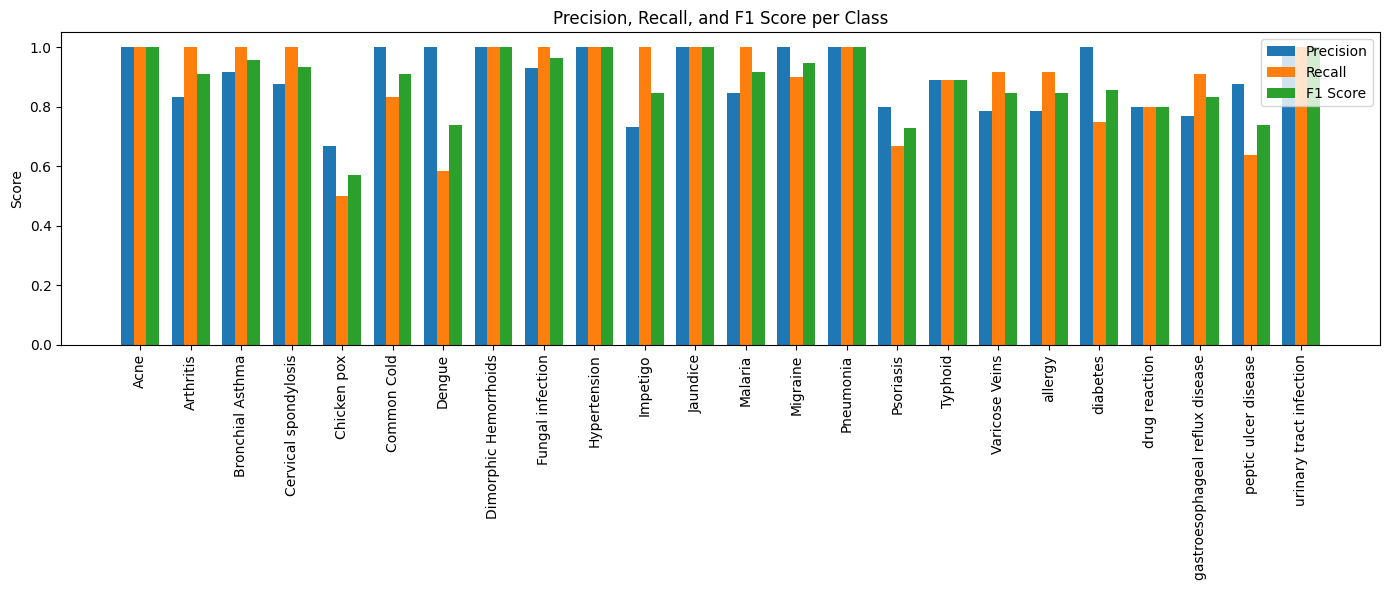

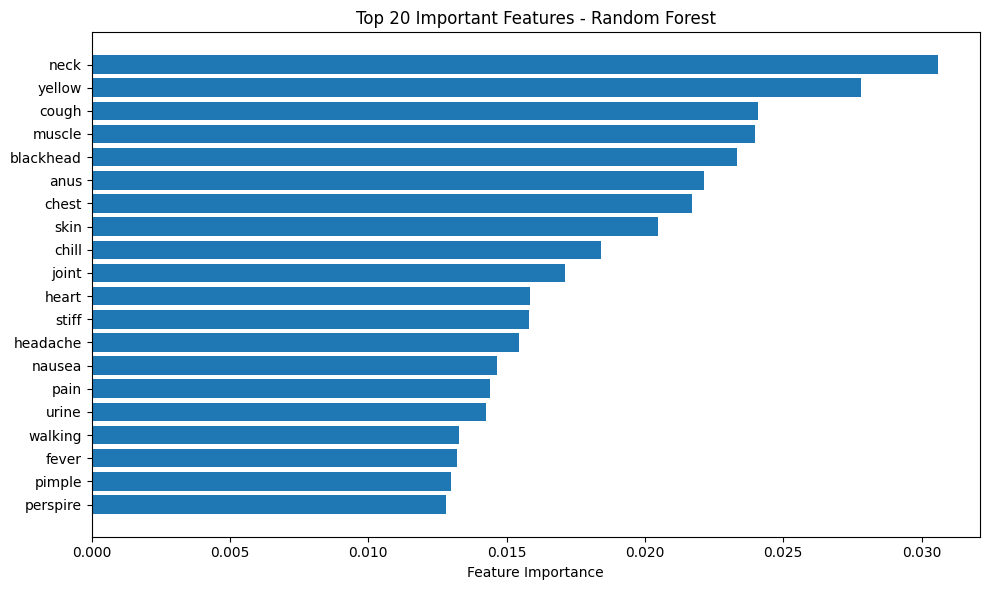

In [36]:
#####adabost#####

import pandas as pd
import numpy as np
import pickle
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, precision_recall_fscore_support

# === Load data ===
df = pd.read_csv('cleaned_medical_symptoms.csv')

# === Vectorize text ===
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(df['cleaned_text'].astype(str))

# === Encode labels ===
le = LabelEncoder()
y = le.fit_transform(df['label'].astype(str))

# Optional: save vectorizer and label encoder
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
joblib.dump(le, 'label_encoder.pkl')
pd.Series(le.classes_).to_csv('disease_classes.csv', index=False, header=False)

# === Split data ===
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42)

# === Train model ===
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)

# Optional: save model
joblib.dump(model, 'random_forest_model.pkl')

# === Predict on test set ===
y_pred = model.predict(X_test)

# === Print classification report ===
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# === Plot Confusion Matrix ===
plt.figure(figsize=(12, 10))
ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test, display_labels=le.classes_, cmap=plt.cm.Blues, xticks_rotation=90)
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

# === Plot Precision, Recall, F1-score per class ===
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
classes = le.classes_

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, precision, width, label='Precision')
ax.bar(x, recall, width, label='Recall')
ax.bar(x + width, f1, width, label='F1 Score')

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=90)
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1 Score per Class')
ax.legend()
plt.tight_layout()
plt.show()

# === Plot top 20 feature importances ===
feature_names = vectorizer.get_feature_names_out()
importances = model.feature_importances_
top_indices = np.argsort(importances)[-20:][::-1]

plt.figure(figsize=(10, 6))
plt.barh(feature_names[top_indices], importances[top_indices])
plt.xlabel("Feature Importance")
plt.title("Top 20 Important Features - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Classification Report:
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00         7
                      Arthritis       0.31      1.00      0.48        10
               Bronchial Asthma       0.52      1.00      0.69        11
           Cervical spondylosis       1.00      0.71      0.83         7
                    Chicken pox       0.00      0.00      0.00        12
                    Common Cold       0.00      0.00      0.00        12
                         Dengue       0.00      0.00      0.00        12
          Dimorphic Hemorrhoids       1.00      1.00      1.00         7
               Fungal infection       0.00      0.00      0.00        13
                   Hypertension       0.00      0.00      0.00        10
                       Impetigo       0.00      0.00      0.00        11
                       Jaundice       0.69      1.00      0.81        11
                        Mal

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 1200x1000 with 0 Axes>

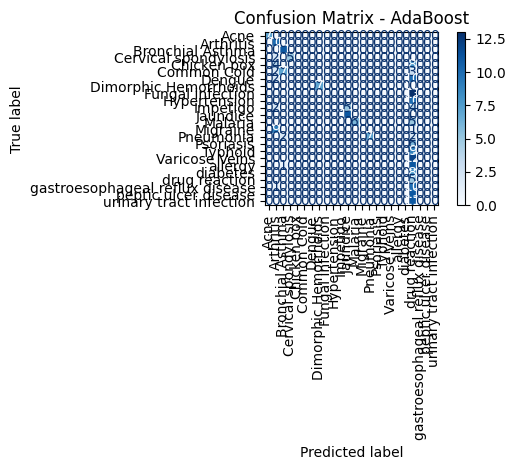

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


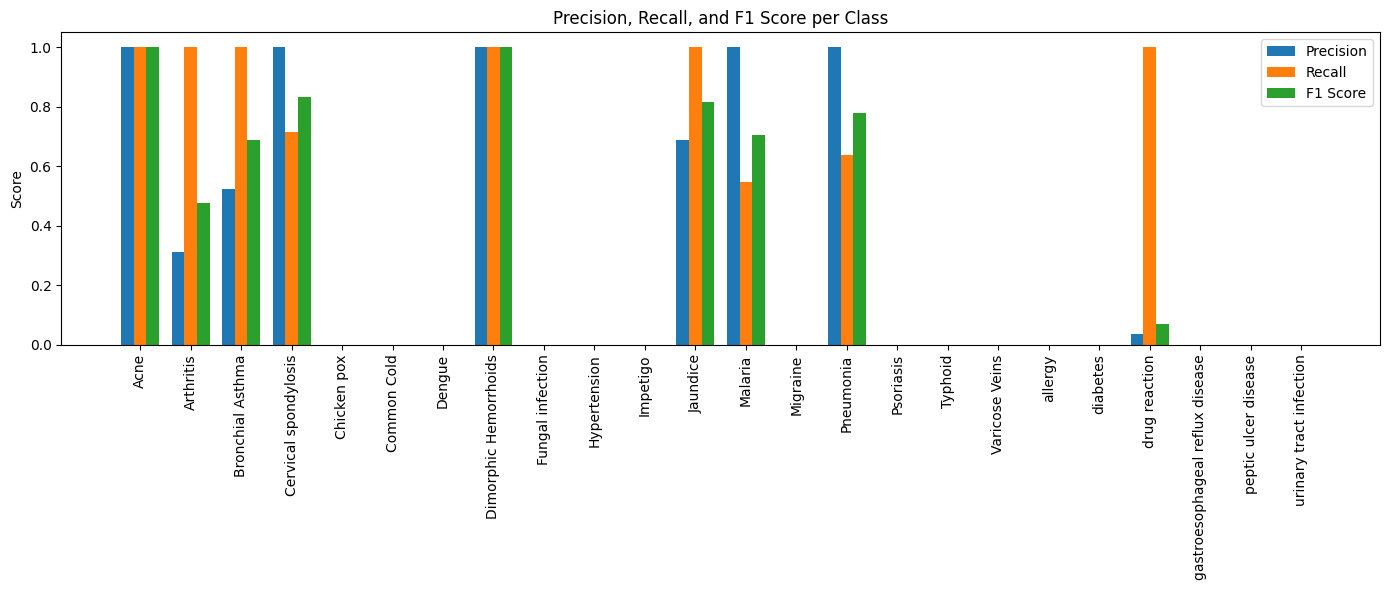

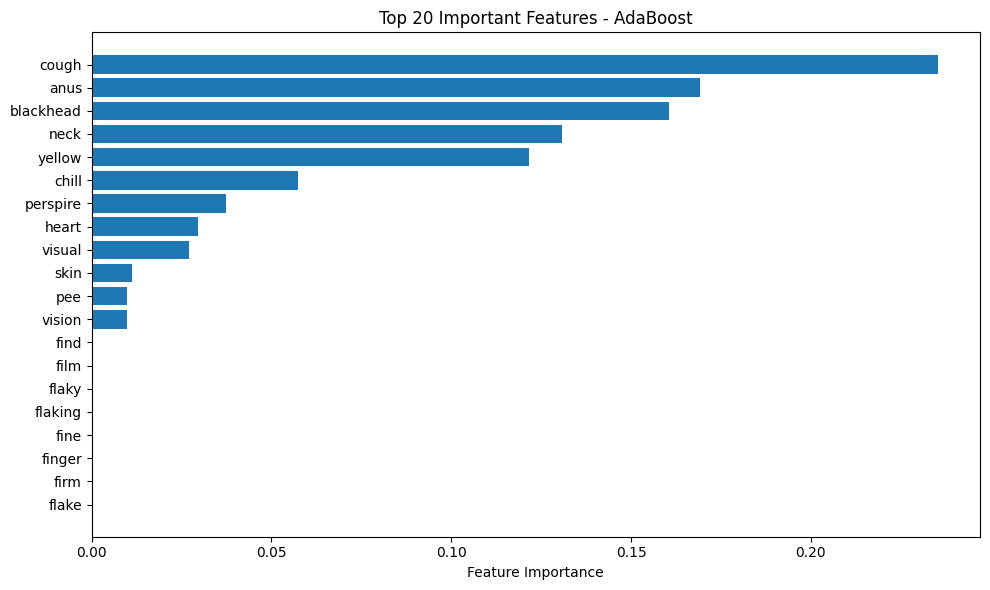

In [38]:


import pandas as pd
import numpy as np
import pickle
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, precision_recall_fscore_support

# === Load data ===
df = pd.read_csv('cleaned_medical_symptoms.csv')

# === Vectorize text ===
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(df['cleaned_text'].astype(str))

# === Encode labels ===
le = LabelEncoder()
y = le.fit_transform(df['label'].astype(str))

# Optional: save vectorizer and label encoder
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
joblib.dump(le, 'label_encoder.pkl')
pd.Series(le.classes_).to_csv('disease_classes.csv', index=False, header=False)

# === Split data ===
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42)

# === Train AdaBoost model ===
ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
ada_model.fit(X_train, y_train)



# === Predict on test set ===
y_pred = ada_model.predict(X_test)

# === Print classification report ===
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# === Plot Confusion Matrix ===
plt.figure(figsize=(12, 10))
ConfusionMatrixDisplay.from_estimator(
    ada_model, X_test, y_test, display_labels=le.classes_, cmap=plt.cm.Blues, xticks_rotation=90)
plt.title("Confusion Matrix - AdaBoost")
plt.tight_layout()
plt.show()

# === Plot Precision, Recall, F1-score per class ===
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
classes = le.classes_

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, precision, width, label='Precision')
ax.bar(x, recall, width, label='Recall')
ax.bar(x + width, f1, width, label='F1 Score')

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=90)
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1 Score per Class')
ax.legend()
plt.tight_layout()
plt.show()

# === Plot top 20 feature importances ===
feature_names = vectorizer.get_feature_names_out()
importances = ada_model.feature_importances_
top_indices = np.argsort(importances)[-20:][::-1]

plt.figure(figsize=(10, 6))
plt.barh(feature_names[top_indices], importances[top_indices])
plt.xlabel("Feature Importance")
plt.title("Top 20 Important Features - AdaBoost")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 162ms/step - accuracy: 0.0338 - loss: 3.1799 - val_accuracy: 0.0417 - val_loss: 3.1825
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.0398 - loss: 3.1788 - val_accuracy: 0.0208 - val_loss: 3.1806
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.0355 - loss: 3.1788 - val_accuracy: 0.0208 - val_loss: 3.1814
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.0344 - loss: 3.1779 - val_accuracy: 0.0208 - val_loss: 3.1842
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.0441 - loss: 3.1773 - val_accuracy: 0.0208 - val_loss: 3.1847
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.0278 - loss: 3.1785 - val_accuracy: 0.0208 - val_loss: 3.1828
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.0413 - loss: 3.1787 - val_accuracy: 0.0208 - val_loss: 3.1857
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.0389 - loss: 3.1778 - val_accuracy: 0.0208

5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                                 precision    recall  f1-score   support

                           Acne       0.00      0.00      0.00        10
                      Arthritis       0.00      0.00      0.00        10
               Bronchial Asthma       0.00      0.00      0.00        10
           Cervical spondylosis       0.00      0.00      0.00        10
                    Chicken pox       0.00      0.00      0.00        10
                    Common Cold       0.00      0.00      0.00        10
                         Dengue       0.04      1.00      0.08        10
          Dimorphic Hemorrhoids       0.00      0.00      0.00        10
               Fungal infection       0.00      0.00      0.00        10
                   Hypertension       0.00      0.00      0.00        10
                       Impetigo       0.00      0.00      0.00        10
                       Jaundice       0.00      0.00      0.00        10
                        Malaria       0.00      0.

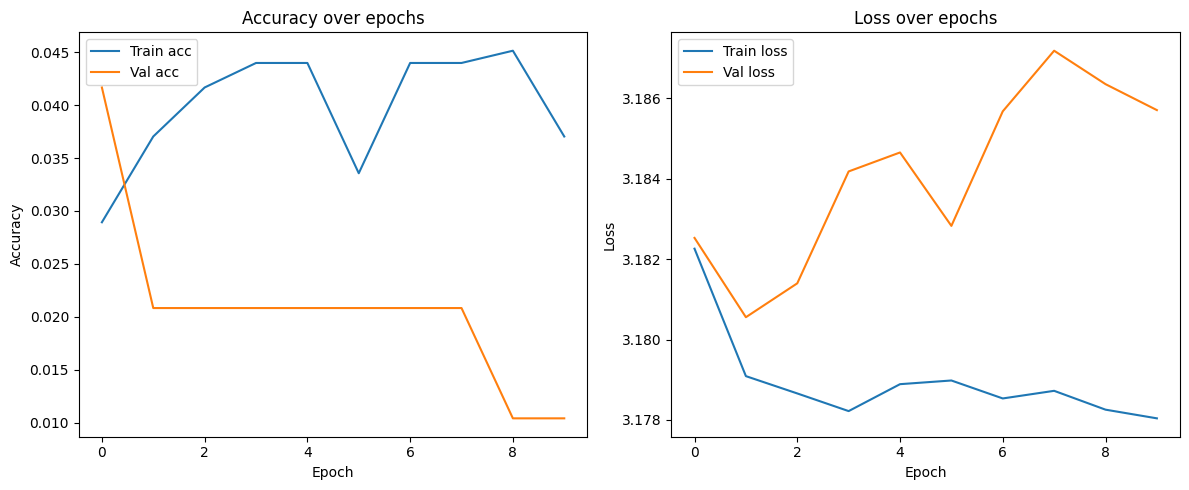

In [39]:
########lstmm##########

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical

# --- Load data ---
df = pd.read_csv('cleaned_medical_symptoms.csv')

texts = df['cleaned_text'].astype(str).tolist()
labels = df['label'].astype(str).tolist()

# --- Encode labels ---
le = LabelEncoder()
y = le.fit_transform(labels)

# Optional: save label encoder classes
pd.Series(le.classes_).to_csv('disease_classes.csv', index=False, header=False)

# --- Tokenize text ---
max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Build LSTM model ---
model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    LSTM(64),
    Dense(64, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- Train model ---
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# --- Evaluate model ---
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

# --- Plot training history ---
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Colab propose désormais des fonctionnalités d'IA fournies par <a href="https://gemini.google.com">Gemini</a>. La vidéo ci-dessous explique comment utiliser ces fonctionnalités, que vous soyez débutant ou utilisateur expérimenté de Python.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  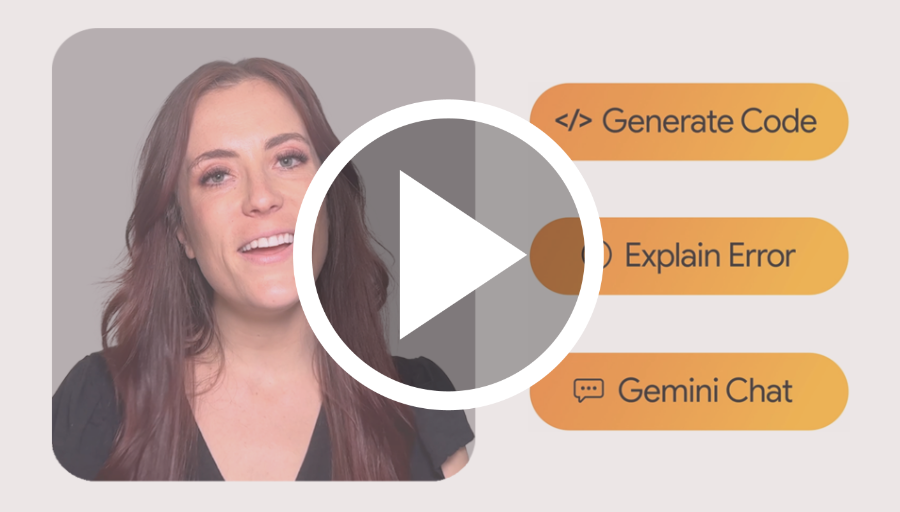
  </a>
</center>

<div class="markdown-google-sans">
  <h2>Qu'est-ce que Colab ?</h2>
</div>

Colab &#40;ou "Colaboratory"&#41; vous permet d'écrire et d'exécuter du code Python dans votre navigateur avec
- Aucune configuration requise
- Accès sans frais aux GPU
- Partage facile

Que vous soyez <strong>étudiant</strong>, <strong>data scientist</strong> ou <strong>chercheur en IA</strong>, Colab peut rendre votre travail plus simple. Regardez <a href="https://www.youtube.com/watch?v=inN8seMm7UI">Introduction to Colab</a> &#40;Présentation de Colab&#41; ou <a href="https://www.youtube.com/watch?v=rNgswRZ2C1Y">Colab Features You May Have Missed</a> &#40;Connaissez-vous ces fonctionnalités Colab ?&#41; pour en savoir plus, ou lancez-vous ci-dessous.

<div class="markdown-google-sans">

## <strong>Premiers pas</strong>
</div>

Le document que vous consultez n'est pas une page Web statique, mais un environnement interactif appelé <strong>notebook Colab</strong>, qui vous permet d'écrire et d'exécuter du code.

Voici par exemple une <strong>cellule de code</strong> avec un bref script en Python qui calcule une valeur, l'enregistre dans une variable et imprime le résultat :

Pour exécuter le code dans la cellule ci-dessus, sélectionnez-le en cliquant dessus, puis cliquez sur le bouton de lecture à gauche du code ou utilisez le raccourci clavier Commande/Ctrl+Entrée. Pour modifier le code, cliquez simplement sur la cellule.

Les variables que vous définissez dans une cellule peuvent être utilisées par la suite dans d'autres cellules :

Les notebooks Colab vous permettent d'utiliser, dans un même document, du <strong>code exécutable</strong>, du <strong>texte enrichi</strong>, des <strong>images</strong>, du code <strong>HTML</strong>, du code <strong>LaTeX</strong> et bien plus. Lorsque vous créez des notebooks Colab, ils sont enregistrés dans votre compte Google Drive. Vous pouvez facilement les partager avec vos collaborateurs ou vos amis, qui peuvent alors y apporter des commentaires ou même les modifier. Pour en savoir plus, consultez la page <a href="/notebooks/basic_features_overview.ipynb">Présentation de Colaboratory</a>. Pour créer un notebook Colab, utilisez le menu "Fichier" ci-dessus ou le lien <a href="http://colab.research.google.com#create=true">Créer un notebook Colab</a>.

Les notebooks Colab sont des notebooks Jupyter hébergés par Colab. Pour en savoir plus sur le projet Jupyter, consultez le site Web <a href="https://www.jupyter.org">jupyter.org</a>.

<div class="markdown-google-sans">

## Data science
</div>

Colab vous permet de tirer pleinement parti des bibliothèques populaires Python pour analyser et visualiser des données. La cellule de code ci-dessous utilise <strong>numpy</strong> pour générer des données aléatoires et <strong>matplotlib</strong> pour les visualiser. Pour modifier le code, cliquez simplement sur la cellule.

Vous pouvez importer vos propres données dans les notebooks Colab depuis votre compte Google Drive, y compris depuis des feuilles de calcul, ainsi que depuis GitHub et de nombreuses autres sources. Pour en savoir plus sur l'importation de données et l'utilisation de Colab dans le domaine de la data science, consultez les liens ci-dessous dans la section <a href="#working-with-data">Utiliser les données</a>.

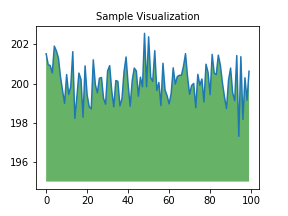

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Les notebooks Colab exécutent ce code sur les serveurs cloud de Google. Vous pouvez donc bénéficier de toute la puissance du matériel Google, y compris les <a href="#using-accelerated-hardware">GPU et TPU</a>, quelle que soit la puissance de votre ordinateur. Vous n'avez besoin que d'un navigateur.

Par exemple, si vous attendez que le code <strong>pandas</strong> termine de s'exécuter et que vous souhaitez accélérer le processus, vous pouvez passer à un environnement d'exécution GPU et utiliser des bibliothèques telles que <a href="https://rapids.ai/cudf-pandas">RAPIDS cuDF</a>, qui fournissent une accélération sans modification de code.

Pour en savoir plus sur l'accélération de pandas dans Colab, consultez le <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb">guide de 10 minutes</a> ou la <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb">démo d'analyse des données boursières aux États-Unis</a>.

<div class="markdown-google-sans">

## Machine learning
</div>

Colab vous permet d'importer un ensemble de données d'images, d'entraîner un classificateur d'images sur cet ensemble et d'évaluer le modèle, tout cela avec <a href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb">quelques lignes de code</a>.

Colab est très largement utilisé par la communauté du machine learning, par exemple dans les applications suivantes :
- Premiers pas avec TensorFlow
- Développement et entraînement de réseaux de neurones
- Expérimentation avec les TPU
- Dissémination de la recherche en IA
- Création de tutoriels

Pour voir comment les notebooks Colab sont utilisés dans des applications de machine learning, reportez-vous aux <a href="#machine-learning-examples">exemples de machine learning</a> ci-dessous.

<div class="markdown-google-sans">

## Autres ressources

### Utiliser les notebooks dans Colab

</div>

- [Présentation de Colab](/notebooks/basic_features_overview.ipynb)
- [Guide de Markdown](/notebooks/markdown_guide.ipynb)
- [Importer des bibliothèques et installer des dépendances](/notebooks/snippets/importing_libraries.ipynb)
- [Enregistrer et charger des notebooks dans GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Formulaires interactifs](/notebooks/forms.ipynb)
- [Widgets interactifs](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Utiliser les données
</div>

- [Chargement de données : Drive, Sheets et Google Cloud Storage](/notebooks/io.ipynb)
- [Graphiques : visualiser les données](/notebooks/charts.ipynb)
- [Premiers pas avec BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine learning

<div>

Voici quelques notebooks liés au machine learning, y compris le cours en ligne de Google sur ce sujet. Consultez la <a href="https://developers.google.com/machine-learning/crash-course/">formation complète en ligne</a> pour en savoir plus.
- [Présentation du DataFrame pandas](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Présentation de RAPIDS cuDF pour accélérer pandas](https://nvda.ws/rapids-cudf)
- [Premiers pas avec le mode accélérateur de cuML](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)
- [Régression linéaire avec tf.keras et des données synthétiques](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/linear_regression_with_synthetic_data.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Utiliser le matériel accéléré
</div>

- [TensorFlow avec des GPU](/notebooks/gpu.ipynb)
- [TPU dans Colab](/notebooks/tpu.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Exemples

</div>

- <a href="https://tensorflow.org/hub/tutorials/tf2_image_retraining">Recyclage d'un classificateur d'images</a> : construisez un modèle Keras sur un classificateur d'images pré-entraîné pour faire la distinction entre différentes fleurs.
- <a href="https://tensorflow.org/hub/tutorials/tf2_text_classification">Classification de texte</a> : classez des avis sur des films provenant de la base de données IMDB comme <em>positifs</em> ou <em>négatifs</em>.
- <a href="https://tensorflow.org/hub/tutorials/tf2_arbitrary_image_stylization">Transfert de style</a> : utilisez le deep learning pour transférer un style d'une image à une autre.
- <a href="https://tensorflow.org/hub/tutorials/retrieval_with_tf_hub_universal_encoder_qa">Questions/Réponses sur l'encodeur de phrases universel multilingue</a> : utilisez un modèle de machine learning afin de répondre aux questions issues de l'ensemble de données SQuAD.
- <a href="https://tensorflow.org/hub/tutorials/tweening_conv3d">Interpolation vidéo</a> : prédisez ce qui s'est passé entre la première et la dernière image d'une vidéo.
